# Liquid Democracy: Mathematical Formulation and Spatial Evaluation

Liquid democracy allows a voter to either cast a ballot directly or delegate
their voting power to another voter. When the selected delegate also delegates,
this produces a chain through which power is transferred. Here, we describe the
implementation in `electoral_sim.liquid` and examine how delegation affects
ballot weights and election outcomes under approval and score voting.

We build on the spatial framework and welfare measures introduced in the earlier
notebooks, linked below. We first develop the delegation mechanism using ten
voters, including weighted counting, conservation, cycles, and failed chains.
We then compare liquid voting with standard single-winner electoral systems,
distinguishing the effect of delegation from the effect of the underlying
voting rule.

The model supports one delegate per voter and delegation of the whole ballot.
Issue-specific delegation and differences in voter expertise are outside its scope.


---
## Imports and configuration

We use the repository implementation for ballot generation, delegation
resolution, and vote counting. Run the notebook in order from either the
repository root or `notebooks/`, using an environment installed with
`pip install -e ".[dev]"`. The experiment configuration below uses 12 independent
seed blocks, four electorate families, two candidate slates, and three nested
delegation draws per case. All seeds and design parameters are explicit.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from IPython import get_ipython
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in [cwd, *cwd.parents]
     if (path / "electoral_sim" / "liquid.py").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Open this notebook inside the electoral_sim repository.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from electoral_sim.ballots import BallotProfile
from electoral_sim.candidates import fixed_candidates
from electoral_sim.electorate import Electorate
from electoral_sim.liquid import (
    DelegationProfile, LiquidApprovalVoting, LiquidScoreVoting,
)
from electoral_sim.systems import ApprovalVoting, ScoreVoting

get_ipython().run_line_magic("matplotlib", "inline")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.titlepad": 12})
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
SEED = 42
CANDIDATE_COLORS = ["#3574A8", "#8C6BB1", "#D88135"]


---
## 1. Prerequisites and the running example

We use the following material from the existing notebooks:

| Background | Earlier explanation |
|---|---|
| Ideal points, Euclidean preferences, and social choice rules | [Arrow notebook: Preliminaries](arrows_impossibility_theorem.ipynb#Preliminaries) |
| Running electoral systems and inspecting their metrics | [Quick start: Load a single scenario and run](quickstart.ipynb#1.-Load-a-single-scenario-and-run) |
| Population and group welfare as negative mean distance | [Majority versus minority welfare: Preliminary refresher](majority_vs_minority_welfare.ipynb#Preliminary-refresher) |
| Spatial representation versus policy consequences | [Representation versus policy consequences: Preliminaries](representation_vs_policy_consequences.ipynb#Preliminaries) |

For the calculations below, $x_i$ denotes voter $i$'s position, $c_k$ denotes
candidate $k$'s position, and $N$ and $K$ are the voter and candidate counts.
Indices start at zero. We use ten voters on a single policy axis and three
fixed candidates.

The example uses sincere approval and score ballots from
`BallotProfile.from_preferences`. With $d_{ik}=|x_i-c_k|$, approval uses an
explicit distance threshold of 0.16 and score uses $s_{ik}=1-d_{ik}$. The package
ensures that each voter approves at least their nearest candidate; that fallback
is not needed here. Scores are not rescaled to give every voter's favorite a 1.

We retain the original voter positions when evaluating outcomes. Delegation
changes whose ballot represents a voter, not that voter's true preferences.


In [2]:
positions = np.array([0.06, 0.13, 0.20, 0.27, 0.38, 0.48, 0.58, 0.73, 0.84, 0.94])
electorate = Electorate(positions[:, None], dim_names=["policy position"])
candidates = fixed_candidates([[0.15], [0.50], [0.85]], ["Left", "Center", "Right"])
voter_names = [f"V{i}" for i in range(electorate.n_voters)]
APPROVAL_THRESHOLD = 0.16
ballots = BallotProfile.from_preferences(electorate, candidates, APPROVAL_THRESHOLD)

# Each liquid rule is compared with its matching direct-voting baseline.
direct_approval = ApprovalVoting().run(ballots, candidates)
direct_score = ScoreVoting().run(ballots, candidates)


---
## 2. Delegation and transitive resolution

Having defined the original ballots, we next introduce delegation. Each voter
either votes directly or selects one other voter as their delegate. If the
selected voter also delegates, voting power is transferred along the resulting
chain until a final ballot is identified. A final ballot may consequently
represent several original voters.

For example, consider V0 delegating to V1 and V1 delegating to V2, where V2
votes directly. If V3 also delegates to V2, the ballot of V2 represents four
units of power, corresponding to V0, V1, V2, and V3. We use this configuration
as part of the ten-voter example below.

The implementation uses `-1` to indicate direct voting. A reference to the
voter's own index is treated in the same way. All ten voters remain active in
this example, including those who delegate. Thus, participation by delegation
is distinct from abstention.


In [3]:
delegation = DelegationProfile([1, 2, -1, 2, 5, -1, 5, 8, 9, -1])
resolution = delegation.resolve(ballots.active_voter_mask)

def delegation_table(profile, resolved):
    targets = profile.delegates
    return pd.DataFrame({
        "Voter": [f"V{i}" for i in range(profile.n_voters)],
        "Instruction": ["Direct" if target in (-1, i) else f"Delegate to V{target}"
                        for i, target in enumerate(targets)],
        "Final ballot": ["Unrepresented" if dest < 0 else f"V{dest}"
                         for dest in resolved.destinations],
        "Weight cast here": resolved.effective_weights,
    })

display(delegation_table(delegation, resolution))
np.testing.assert_array_equal(resolution.effective_weights, [0, 0, 4, 0, 0, 3, 0, 0, 0, 3])
assert resolution.represented_power == electorate.n_voters


,Voter,Instruction,Final ballot,Weight cast here
0,V0,Delegate to V1,V2,0
1,V1,Delegate to V2,V2,0
2,V2,Direct,V2,4
3,V3,Delegate to V2,V2,0
4,V4,Delegate to V5,V5,0
5,V5,Direct,V5,3
6,V6,Delegate to V5,V5,0
7,V7,Delegate to V8,V9,0
8,V8,Delegate to V9,V9,0
9,V9,Direct,V9,3


### Visualization of delegation chains

The following figure shows the requested delegation instructions as directed
edges. Node area indicates the power cast at each voter after resolution,
with a minimum area retained to display voters whose own ballots receive zero
weight. Horizontal positions follow the policy axis, while vertical positions
are chosen for readability. The labels report the final ballot weights.


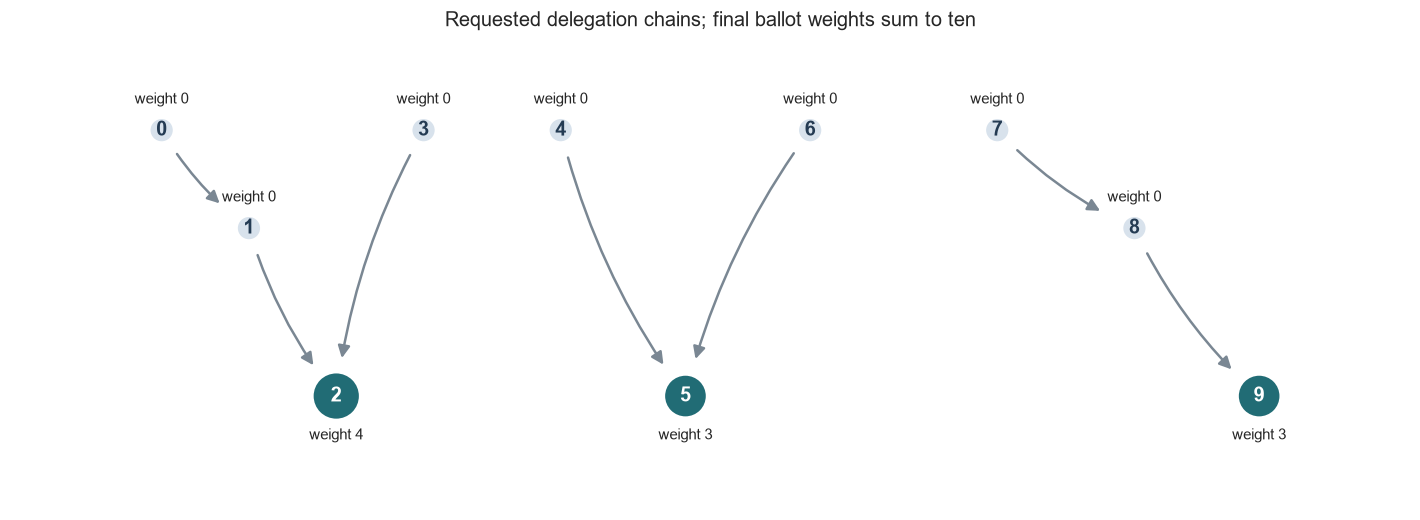

In [4]:
def draw_delegations(profile, resolved, coordinates, ax, title):
    targets = profile.delegates
    for i, target in enumerate(targets):
        if target >= 0 and target != i:
            arrow = FancyArrowPatch(
                coordinates[i], coordinates[target], arrowstyle="-|>",
                mutation_scale=15, color="#7A8793", linewidth=1.5,
                shrinkA=17, shrinkB=23, connectionstyle="arc3,rad=0.10", zorder=1,
            )
            ax.add_patch(arrow)
    weights = resolved.effective_weights
    ax.scatter(coordinates[:, 0], coordinates[:, 1],
               s=220 + 150 * weights, c=np.where(weights > 0, "#216C75", "#D8E2EC"),
               edgecolors="white", linewidths=1.5, zorder=2)
    for i, (x, y) in enumerate(coordinates):
        ax.text(x, y, str(i), ha="center", va="center", zorder=3,
                color="white" if weights[i] > 0 else "#243B53", weight="bold")
        label_offset = -26 if weights[i] > 0 else 16
        ax.annotate(f"weight {weights[i]}", (x, y), xytext=(0, label_offset),
                    textcoords="offset points", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_xlim(coordinates[:, 0].min() - 0.12, coordinates[:, 0].max() + 0.12)
    ax.set_ylim(coordinates[:, 1].min() - 0.4, coordinates[:, 1].max() + 0.3)
    ax.axis("off")

layout = np.column_stack([positions, [1.0, 0.65, 0.05, 1.0, 1.0, 0.05, 1.0, 1.0, 0.65, 0.05]])
fig, ax = plt.subplots(figsize=(12, 4.5))
draw_delegations(delegation, resolution, layout, ax,
                 "Requested delegation chains; final ballot weights sum to ten")
fig.tight_layout()
plt.show()


---
## 3. Mathematical formulation of delegated voting

We first define the quantities required to distinguish participation from
representation. Let $a_i\in\{0,1\}$ indicate whether voter $i$ participates,
and let $r(i)$ denote the voter whose ballot ultimately represents $i$. If no
ballot represents $i$, we write $r(i)=\bot$, corresponding to `-1` in the
implementation. Inactive voters also have destination $\bot$.

Given the resolved destinations, the effective weight of voter $j$'s ballot is

$$w_j=\sum_{i=0}^{N-1}a_i\,\mathbf{1}\{r(i)=j\}.$$

Here, each active voter contributes one unit to the ballot at their final
destination. We define participating power $P$, represented power $M$, and
unrepresented power $U$ as follows:

$$P=\sum_i a_i,\qquad M=\sum_j w_j,\qquad
U=\sum_i a_i\,\mathbf{1}\{r(i)=\bot\}.$$

Since each active voter is either represented at exactly one destination or
unrepresented, these quantities satisfy

$$M+U=P.$$

This identity provides a check that delegation does not create additional voting
power. In the present example, $P=M=10$ and $U=0$. A direct voter's ballot
receives their own unit together with any units delegated to them. A delegator's
own ballot has zero weight, although the delegator can still be represented
by another ballot.

For $M>0$, the approval total and mean score for candidate $k$ are respectively
given by

$$A_k=\sum_j w_j b_{jk},\qquad
S_k=\frac{1}{M}\sum_j w_j s_{jk}.$$

The candidate with the largest value is selected. In the case of a tie, the
lowest candidate index is used, consistent with the package's direct approval
and score rules. The following calculation compares these expressions with
the implementation outputs.


In [5]:
weights = resolution.effective_weights
manual_approvals = weights @ ballots.approvals
manual_scores = (weights @ ballots.scores) / resolution.represented_power
liquid_approval = LiquidApprovalVoting(delegation).run(ballots, candidates)
liquid_score = LiquidScoreVoting(delegation).run(ballots, candidates)

np.testing.assert_allclose(manual_approvals, liquid_approval.metadata["approval_counts"])
np.testing.assert_allclose(manual_scores, liquid_score.metadata["mean_scores"])
assert resolution.represented_power + resolution.unrepresented_power == resolution.participating_power

display(pd.DataFrame({
    "Candidate": candidates.labels,
    "Direct approvals": direct_approval.metadata["approval_counts"],
    "Liquid approvals": manual_approvals,
    "Direct mean score": direct_score.metadata["mean_scores"],
    "Liquid mean score": manual_scores,
}))


,Candidate,Direct approvals,Liquid approvals,Direct mean score,Liquid mean score
0,Left,4,4,0.667,0.644
1,Center,3,3,0.743,0.742
2,Right,3,3,0.593,0.602


In this example, each delegation chain remains within one of the three approval
blocs. Consequently, the approval totals are unchanged. The score totals differ
because voters within a bloc can assign different scores to the same candidates.
The score winner nevertheless remains Center. This observation applies to the
chosen network and does not establish outcome preservation under delegation
more generally.

### Matrix interpretation

The same calculation can be expressed using a resolution matrix. Define the
$N\times N$ matrix $R$ by $R_{ij}=a_i\mathbf{1}\{r(i)=j\}$. Each
represented voter's row contains one nonzero entry, while inactive and
unrepresented voters have zero rows. Given the approval matrix $B$, the product
$RB$ assigns the final delegate's ballot to each represented voter. The column
sums of $R$ give $w$, and the approval tally satisfies

$$\mathbf{1}^{\mathsf T}RB=w^{\mathsf T}B.$$

Hence, weighting the final delegates' ballots is equivalent to explicitly
replicating those ballots for the voters they represent. We construct $R$ below
to illustrate this equivalence for ten voters. The implementation resolves the
delegation graph directly and does not construct this dense matrix.


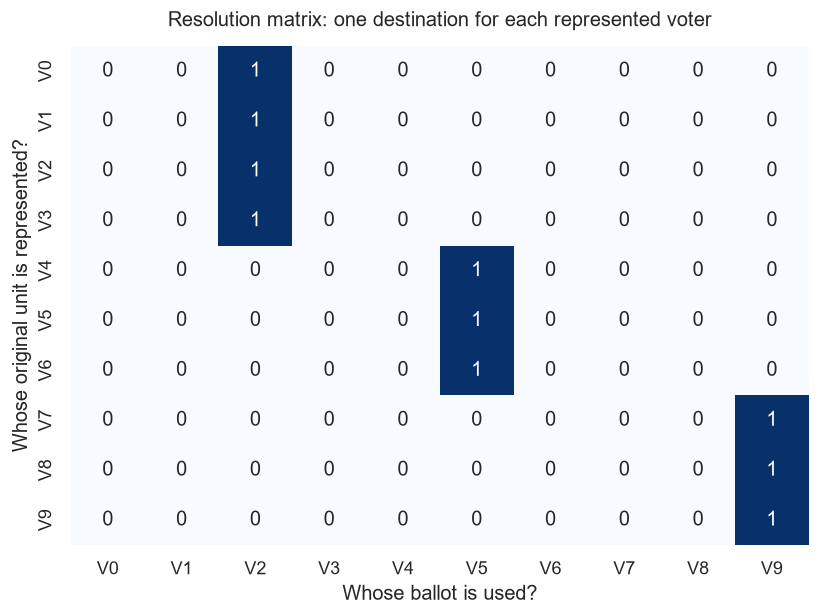

In [6]:
R = np.zeros((electorate.n_voters, electorate.n_voters), dtype=int)
represented_rows = np.flatnonzero(resolution.destinations >= 0)
R[represented_rows, resolution.destinations[represented_rows]] = 1
np.testing.assert_array_equal(R.sum(axis=0), weights)
np.testing.assert_array_equal((R @ ballots.approvals).sum(axis=0), manual_approvals)

fig, ax = plt.subplots(figsize=(7, 5.3))
sns.heatmap(R, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=voter_names, yticklabels=voter_names, ax=ax)
ax.set(xlabel="Whose ballot is used?", ylabel="Whose original unit is represented?",
       title="Resolution matrix: one destination for each represented voter")
fig.tight_layout()
plt.show()


### Recovery of direct voting

In the absence of delegation, $r(i)=i$ for each active voter and $w_i=a_i$.
Substituting these weights into the tally expressions recovers ordinary approval
and score voting. We verify this property numerically below by comparing the
liquid rules with their direct-voting counterparts. This check establishes
agreement in the no-delegation case only.


In [7]:
all_direct = DelegationProfile(np.full(electorate.n_voters, -1, dtype=int))
no_delegation_approval = LiquidApprovalVoting(all_direct).run(ballots, candidates)
no_delegation_score = LiquidScoreVoting(all_direct).run(ballots, candidates)
np.testing.assert_array_equal(no_delegation_approval.metadata["approval_counts"],
                              direct_approval.metadata["approval_counts"])
np.testing.assert_allclose(no_delegation_score.metadata["mean_scores"],
                           direct_score.metadata["mean_scores"])
print("No-delegation check passed for both voting rules.")


No-delegation check passed for both voting rules.


---
## 4. Effect of concentrated delegation on the outcome

To examine the effect of concentration, we next assign V9 as the final delegate
for all ten voters. All original units of voting power remain represented, but
the resulting tally uses the ballot of a single voter. This example allows us
to distinguish conservation of voting power from representation of the original
preferences.

We keep the voter and candidate positions fixed and change only the delegation
instructions. The assignment to V9 is chosen to illustrate an extreme case;
we do not model the process through which this voter acquires trust, possesses
additional information, or remains a preferred delegate over time.


,Delegation,Rule,Winner,Mean voter distance
0,Direct,LiquidApprovalVoting,Left,0.333
1,Direct,LiquidScoreVoting,Center,0.257
2,Local chains,LiquidApprovalVoting,Left,0.333
3,Local chains,LiquidScoreVoting,Center,0.257
4,Everyone to V9,LiquidApprovalVoting,Right,0.407
5,Everyone to V9,LiquidScoreVoting,Right,0.407


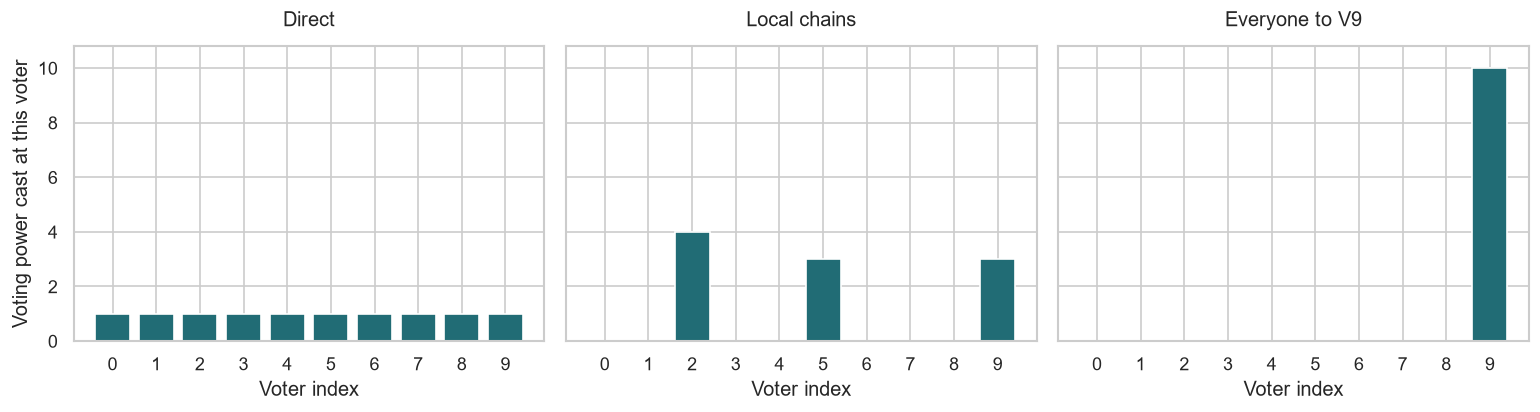

In [8]:
popular_profile = DelegationProfile([9] * 9 + [-1])
popular_resolution = popular_profile.resolve()
profiles = {"Direct": all_direct, "Local chains": delegation, "Everyone to V9": popular_profile}
comparison_rows = []
for label, profile in profiles.items():
    for rule in [LiquidApprovalVoting, LiquidScoreVoting]:
        result = rule(profile).run(ballots, candidates)
        # Evaluate the elected candidate against ALL original voter preferences.
        distance = np.abs(positions - result.outcome_position[0]).mean()
        comparison_rows.append({"Delegation": label, "Rule": rule.__name__,
                                "Winner": candidates.labels[result.winner_indices[0]],
                                "Mean voter distance": distance})
display(pd.DataFrame(comparison_rows))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, (label, profile) in zip(axes, profiles.items()):
    ax.bar(np.arange(10), profile.resolve().effective_weights, color="#216C75")
    ax.set(title=label, xlabel="Voter index", xticks=np.arange(10), ylim=(0, 10.8))
axes[0].set_ylabel("Voting power cast at this voter")
fig.tight_layout()
plt.show()


Both liquid rules select Right when all voters delegate to V9. Since voter and
candidate positions are fixed, this change is attributable to the redistribution
of ballot weights. All ten units remain represented, demonstrating that power
conservation alone does not preserve the direct-voting outcome.


---
## 5. Resolution of delegation cycles

A delegation chain need not terminate at a direct voter. For example, if V0
delegates to V1 and V1 delegates to V0, the two instructions form a cycle.
The delegation mechanism therefore requires an additional rule for resolving
such configurations.

The current implementation uses direct fallback: each cycle member casts their
own ballot, and an incoming chain terminates at the first cycle member it
reaches. For the profile `[1, 0, 1]`, V0 casts one unit and V1 casts two units,
including the unit originating from V2.

This treatment is a convention of the implemented model. Alternative rules
could discard power directed into a cycle or require the affected voters to
choose new delegates. We do not evaluate those alternatives here.


,Voter,Instruction,Final ballot,Weight cast here
0,V0,Delegate to V1,V0,1
1,V1,Delegate to V0,V1,2
2,V2,Delegate to V1,V1,0


Detected cycles: ((0, 1),)


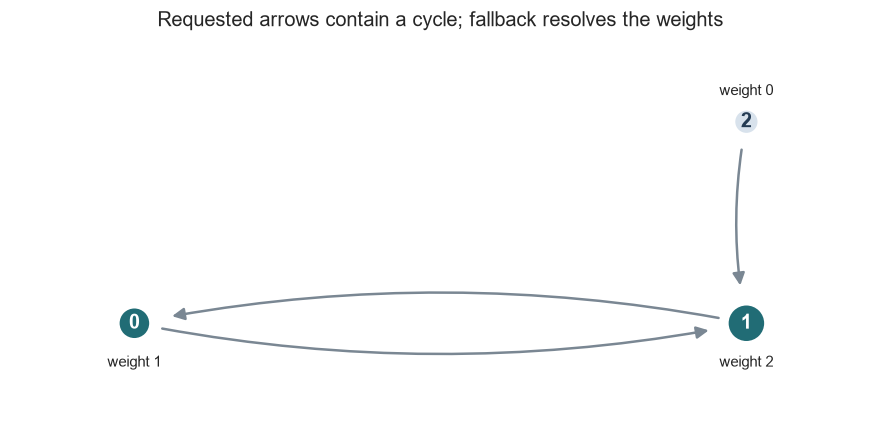

In [9]:
cycle_profile = DelegationProfile([1, 0, 1])
cycle_resolution = cycle_profile.resolve()
display(delegation_table(cycle_profile, cycle_resolution))
print("Detected cycles:", cycle_resolution.cycles)
np.testing.assert_array_equal(cycle_resolution.effective_weights, [1, 2, 0])

fig, ax = plt.subplots(figsize=(7.5, 3.8))
draw_delegations(cycle_profile, cycle_resolution,
                 np.array([[0.1, 0.2], [0.7, 0.2], [0.7, 1.0]]), ax,
                 "Requested arrows contain a cycle; fallback resolves the weights")
fig.tight_layout()
plt.show()


## 6. Abstention and withdrawal of delegation

We next consider the effect of an inactive voter on delegation resolution.
Under the implemented rule, an inactive voter supplies no power and cannot
cast or forward power received from another voter. Consequently, active voters
whose chains reach an inactive voter become unrepresented.

To demonstrate this behavior, we make V2 inactive while retaining the original
delegation profile. V0, V1, and V3 remain active, but their chains no longer
reach a valid ballot. The expected accounting is $P=9$, $M=6$, and $U=3$.
Here, V2's own abstention is excluded from participating power and is not counted
again as an unrepresented active delegation.

Approval rates and mean scores are normalized by $M$, rather than $P$ or $N$.
When $M=0$, the resolution can still be reported, but the election rule does
not declare a winner. The following cell checks both the abstention example
and this zero-power case.


In [10]:
abstention_ballots = BallotProfile.from_preferences(electorate, candidates, APPROVAL_THRESHOLD)
abstention_ballots.active_voter_mask[2] = False
abstention_resolution = delegation.resolve(abstention_ballots.active_voter_mask)
display(delegation_table(delegation, abstention_resolution))
display(pd.DataFrame([{
    "Participating P": abstention_resolution.participating_power,
    "Represented M": abstention_resolution.represented_power,
    "Unrepresented U": abstention_resolution.unrepresented_power,
}]))
assert (abstention_resolution.participating_power,
        abstention_resolution.represented_power,
        abstention_resolution.unrepresented_power) == (9, 6, 3)

abstention_result = LiquidScoreVoting(delegation).run(abstention_ballots, candidates)
print("Score winner after V2 abstains:", candidates.labels[abstention_result.winner_indices[0]])

empty_ballots = BallotProfile.from_preferences(electorate, candidates, APPROVAL_THRESHOLD)
empty_ballots.active_voter_mask[:] = False
try:
    LiquidScoreVoting(delegation).run(empty_ballots, candidates)
except ValueError as error:
    print("Expected no-power case:", error)
else:
    raise AssertionError("An election with no represented power must not elect a winner.")


,Voter,Instruction,Final ballot,Weight cast here
0,V0,Delegate to V1,Unrepresented,0
1,V1,Delegate to V2,Unrepresented,0
2,V2,Direct,Unrepresented,0
3,V3,Delegate to V2,Unrepresented,0
4,V4,Delegate to V5,V5,0
5,V5,Direct,V5,3
6,V6,Delegate to V5,V5,0
7,V7,Delegate to V8,V9,0
8,V8,Delegate to V9,V9,0
9,V9,Direct,V9,3


,Participating P,Represented M,Unrepresented U
0,9,6,3


Score winner after V2 abstains: Center
Expected no-power case: liquid election has no represented voting power


Withdrawal of a delegation has a different effect from abstention. To illustrate
this distinction, we restore full participation and allow V1 to vote directly
by changing their instruction to `-1`. Since V0 continues to delegate to V1,
V1 now casts two units. V2 retains their own unit and the unit delegated by V3.
Thus, changing an intermediary's instruction can also redirect power originating
from other voters.

We implement this change by constructing a revised profile and resolving it
again. The comparison describes two fixed delegation states; it does not model
the timing of withdrawal or continuous updates to the network.


In [11]:
revised_targets = delegation.delegates
revised_targets[1] = -1
revised_profile = DelegationProfile(revised_targets)
revised_resolution = revised_profile.resolve(ballots.active_voter_mask)
display(pd.DataFrame({
    "Voter": voter_names,
    "Original weight": resolution.effective_weights,
    "After V1 votes directly": revised_resolution.effective_weights,
}))
np.testing.assert_array_equal(revised_resolution.effective_weights[:4], [0, 2, 2, 0])
assert revised_resolution.represented_power == 10


,Voter,Original weight,After V1 votes directly
0,V0,0,0
1,V1,0,2
2,V2,4,2
3,V3,0,0
4,V4,0,0
5,V5,3,3
6,V6,0,0
7,V7,0,0
8,V8,0,0
9,V9,3,3


---
## 7. Evaluation of concentration and spatial representation

The purpose of the concentration evaluation is to quantify how represented
power is distributed across final ballots. For $M>0$, let $p_j=w_j/M$ denote
the share cast at voter $j$. We consider the following two summaries:

$$p_{\max}=\max_j p_j,\qquad
N_{\mathrm{eff}}=\frac{1}{\sum_j p_j^2}.$$

Here, $p_{\max}$ is the largest ballot-weight share and $N_{\mathrm{eff}}$
is the effective number of equally weighted ballot casters. If $q$ final voters
hold equal weights, $N_{\mathrm{eff}}=q$; if one voter holds all represented
power, $N_{\mathrm{eff}}=1$. These summaries describe ballot weights. They
do not measure expertise, statistical independence, or the probability that an
individual is pivotal to the outcome.

To evaluate disagreement between voters and their final delegates, we use

$$E=\frac{1}{M}\sum_{i:r(i)\ne\bot}\lVert x_i-x_{r(i)}\rVert_2.$$

Each represented original voter contributes one term to this average. The metric
therefore quantifies spatial disagreement with the selected delegate, without
making assumptions about dishonesty or information loss. Since unrepresented
voters are excluded, $E$ should be interpreted together with $U$.

For outcome evaluation, we reuse the population mean-distance measure from the
[welfare notebook's preliminary refresher](majority_vs_minority_welfare.ipynb#Preliminary-refresher).
We denote it by $L(y)=-W_{\mathrm{agg}}(y)$, so lower values are better. As in
the running example, it is computed over all original voters, including
abstainers. Group-specific definitions and comparisons are developed in that
notebook rather than repeated here.


In [12]:
def delegation_diagnostics(resolved, preferences):
    if resolved.represented_power == 0:
        return {"Largest share": np.nan, "Effective casters": np.nan,
                "Delegate disagreement": np.nan}
    shares = resolved.effective_weights / resolved.represented_power
    mask = resolved.destinations >= 0
    differences = preferences[mask] - preferences[resolved.destinations[mask]]
    return {
        "Largest share": shares.max(),
        "Effective casters": 1.0 / np.square(shares).sum(),
        "Delegate disagreement": np.linalg.norm(differences, axis=1).mean(),
    }

display(pd.DataFrame([
    {"Delegation": name, **delegation_diagnostics(profile.resolve(), electorate.preferences)}
    for name, profile in profiles.items()
]))


,Delegation,Largest share,Effective casters,Delegate disagreement
0,Direct,0.100,10.000,0.000
1,Local chains,0.400,2.941,0.079
2,Everyone to V9,1.000,1.000,0.479


---
## 8. Comparison with standard electoral systems

The experiment asks two related questions. How do liquid approval and
liquid score compare with familiar single-winner rules? What changes specifically
because delegation is introduced? We address the first through a side-by-side
comparison and the second through paired comparisons with direct approval and
direct score on the same electorate.

We include plurality, two-round runoff, IRV, Borda, approval, score, and Schulze,
using their repository implementations. PR systems are excluded because a
comparison of legislative outcomes would additionally require a common policy
resolution model. All reported single-winner outcomes use the elected candidate's
actual position.

### Electorates and candidate availability

| Family | Mixture weights | Two-dimensional bloc centers | Within-bloc standard deviation |
|---|---|---|---|
| Consensus | 1.00 | (0.50, 0.50) | 0.12 |
| Polarized | 0.50, 0.50 | (0.22, 0.42), (0.78, 0.58) | 0.09 |
| Fragmented | 0.34, 0.33, 0.33 | (0.20, 0.25), (0.45, 0.78), (0.82, 0.35) | 0.08 |
| Asymmetric | 0.70, 0.30 | (0.30, 0.40), (0.80, 0.65) | 0.09 |

For each family and seed, we draw 400 voters from spherical Gaussian components
and clip positions to the unit square. Component labels define the groups used
for group-distance calculations. They are synthetic preference blocs, not
demographic categories; the consensus family has only one group.

The broad-coverage slate contains five candidates at (0.18, 0.35), (0.35, 0.72),
(0.50, 0.50), (0.70, 0.28), and (0.84, 0.70). The second slate removes the
central candidate, leaving four. The same voters are used for both slates and
all electoral rules. Sincere approval uses a fixed threshold of 0.25; score
uses the package's distance normalization in two dimensions.

### Delegate selection

We select six distinct voters nearest six fixed policy anchors distributed across
the square (listed in the helper implementation). These representatives remain
direct voters. A fraction of the remaining voters delegates using one of three
mechanisms: **Nearby**, selecting the closest representative; **Random**, selecting
uniformly from the pool; or **Popular**, selecting the pool member with the
largest first-axis position. Popular is an intentionally asymmetric concentration
stress test, not an estimate of real-world popularity. Nearby assumes exact
knowledge of positions.

Fractions range from zero to one in increments of 0.25. At one, the six
representatives still vote directly. Within each network draw, the same nested
sets of delegators are used across mechanisms and voting rules. All voters
remain represented, and delegates vote directly, so the experiment isolates
delegate choice from cycles and failed chains.


### Outcomes and uncertainty

We reuse population mean distance from the
[welfare notebook](majority_vs_minority_welfare.ipynb#Preliminary-refresher),
and additionally report the largest group mean distance. Both use every original
voter. For each liquid rule we calculate the paired difference from its matching
direct rule: negative distance differences indicate improvement. We also record
the shares of voters strictly preferring the liquid winner, strictly preferring
the direct winner, or being indifferent. Identical winners yield 100% indifference,
not a 50–50 preference split. Concentration and unrepresented power are reported
as separate network diagnostics.

An important property of this setup is that sincere score voting already
minimizes population mean distance over the available candidates: maximizing
the average of $1-d_{ik}/\sqrt{2}$ is equivalent to minimizing average distance.
Consequently, liquid score cannot improve this particular objective relative
to full-participation direct score. Group distances and pairwise preferences
measure other properties.

For uncertainty, we first average network draws within each family/slate/seed,
then average scenario cells equally within each seed. We bootstrap these seed
blocks 1,000 times to obtain pointwise 95% percentile intervals. Paired effects
are computed before aggregation. Shared seeds across scenarios and slates are
resampled together; network draws are not treated as independent electorates.
With 12 seed blocks these intervals are illustrative, not population-level or
simultaneous significance claims.


In [13]:
from dataclasses import asdict
import platform
from notebooks.helpers.liquid_experiments import (
    ExperimentConfig, MECHANISMS, STANDARD_RULES,
    run_system_comparison, summarize_by_seed,
)

CONFIG = ExperimentConfig()
SELECTED_FRACTION = 0.75
BOOTSTRAP_DRAWS = 1000
comparison_config = {key: value for key, value in asdict(CONFIG).items()
                     if key != "absence_fractions"}
display(pd.Series(comparison_config, name="Experiment configuration").to_frame())
print(f"Python {platform.python_version()}, NumPy {np.__version__}, pandas {pd.__version__}")

direct_results, liquid_results = run_system_comparison(CONFIG)
assert np.allclose(liquid_results.loc[liquid_results.fraction == 0, "distance_delta"], 0)
assert (liquid_results.represented_power == CONFIG.n_voters).all()
assert (liquid_results.unrepresented_power == 0).all()
assert (liquid_results.loc[liquid_results.system == "Score", "distance_delta"] >= -1e-12).all()
assert np.allclose(liquid_results.prefer_liquid + liquid_results.prefer_direct
                   + liquid_results.indifferent, 1)
print(f"{len(direct_results):,} direct results and {len(liquid_results):,} liquid results.")


,Experiment configuration
seeds,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11)"
network_draws,3
n_voters,400
families,"(Consensus, Polarized, Fragmented, Asymmetric)"
slates,"(Broad coverage, No central candidate)"
delegation_fractions,"(0.0, 0.25, 0.5, 0.75, 1.0)"
approval_threshold,0.250


Python 3.12.14, NumPy 2.5.3, pandas 3.0.6


672 direct results and 8,640 liquid results.


### Complete electoral arrangements

The following comparison uses a delegation fraction of 0.75 among eligible
voters for the liquid systems and full direct participation for standard rules.
Each plotted estimate averages the four families and two slates equally. Lines
show bootstrap intervals over seed blocks. These design averages describe the
specified scenario mixture, not the prevalence of those scenarios in practice.
The next figure separates the paired delegation effects by scenario.


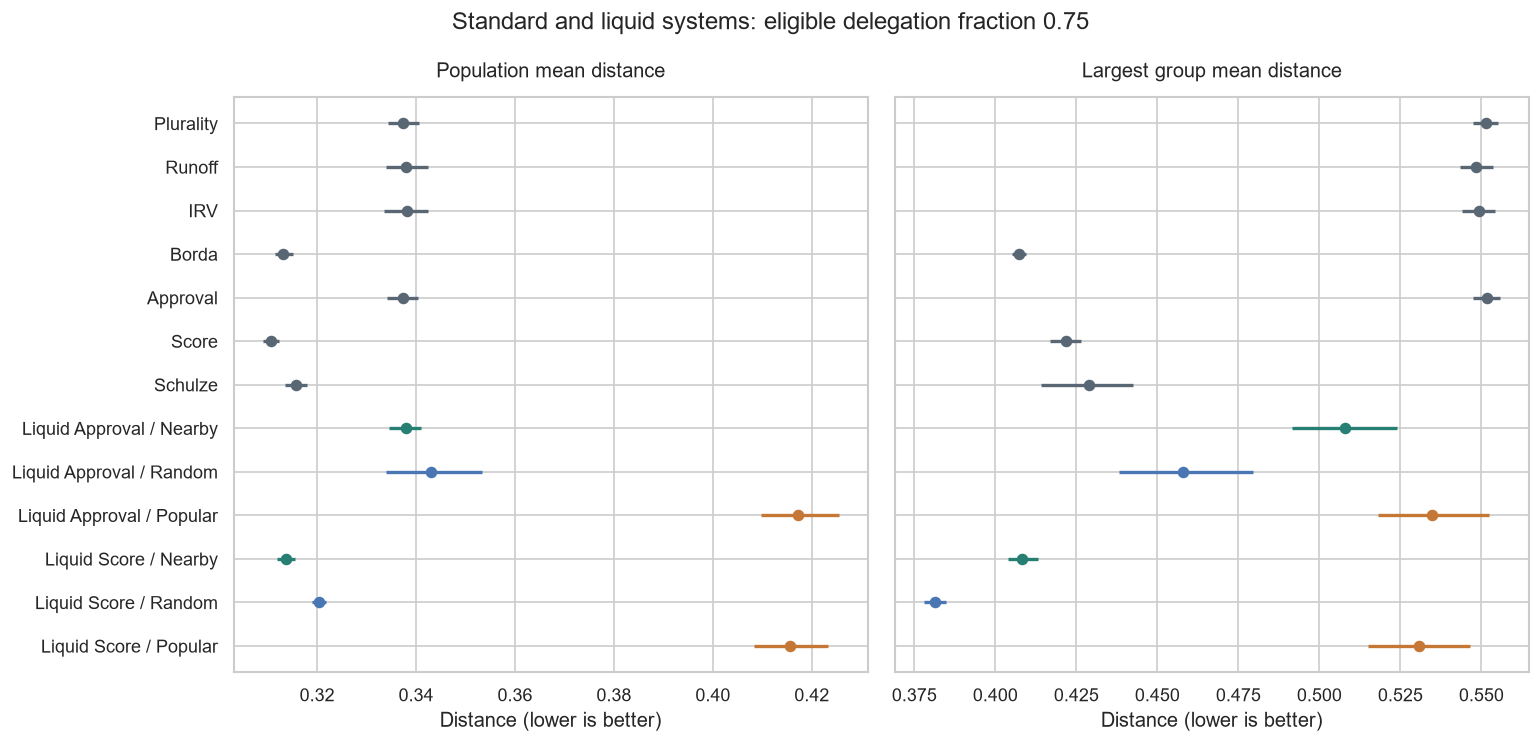

In [14]:
PALETTE = {"Nearby": "#277F73", "Random": "#4B76B4", "Popular": "#C57735"}
direct_view = direct_results.assign(variant=direct_results.system)
liquid_view = liquid_results[liquid_results.fraction == SELECTED_FRACTION].copy()
liquid_view["variant"] = "Liquid " + liquid_view.system + " / " + liquid_view.mechanism
overview = summarize_by_seed(pd.concat([direct_view, liquid_view], ignore_index=True),
                             ["variant"], ["mean_distance", "worst_group_distance"], BOOTSTRAP_DRAWS)
variants = list(STANDARD_RULES) + [f"Liquid {rule} / {m}"
                                  for rule in ["Approval", "Score"] for m in MECHANISMS]
fig, axes = plt.subplots(1, 2, figsize=(13, 6.3), sharey=True)
for ax, metric, title in zip(axes, ["mean_distance", "worst_group_distance"],
                              ["Population mean distance", "Largest group mean distance"]):
    table = overview[overview.metric == metric].set_index("variant").loc[variants]
    for y, (label, row) in enumerate(table.iterrows()):
        color = PALETTE[label.split(" / ")[-1]] if " / " in label else "#596775"
        ax.hlines(y, row.low, row.high, color=color, linewidth=2)
        ax.scatter(row["mean"], y, color=color, s=35, zorder=3)
    ax.set(title=title, xlabel="Distance (lower is better)", yticks=np.arange(len(variants)))
axes[0].set_yticklabels(variants)
axes[0].invert_yaxis()
fig.suptitle(f"Standard and liquid systems: eligible delegation fraction {SELECTED_FRACTION:.2f}")
fig.tight_layout()
plt.show()


### Isolating the effect of delegation

Each heatmap entry is the mean within-case change in population distance from
the corresponding direct rule at the selected delegation fraction. Colors share
a common scale; zero means no change in this metric. The table below provides
pooled paired estimates with uncertainty and the voter preference shares.
The heatmaps show means only; scenario-specific uncertainty can be obtained
from `scenario_effects` in the next cell.


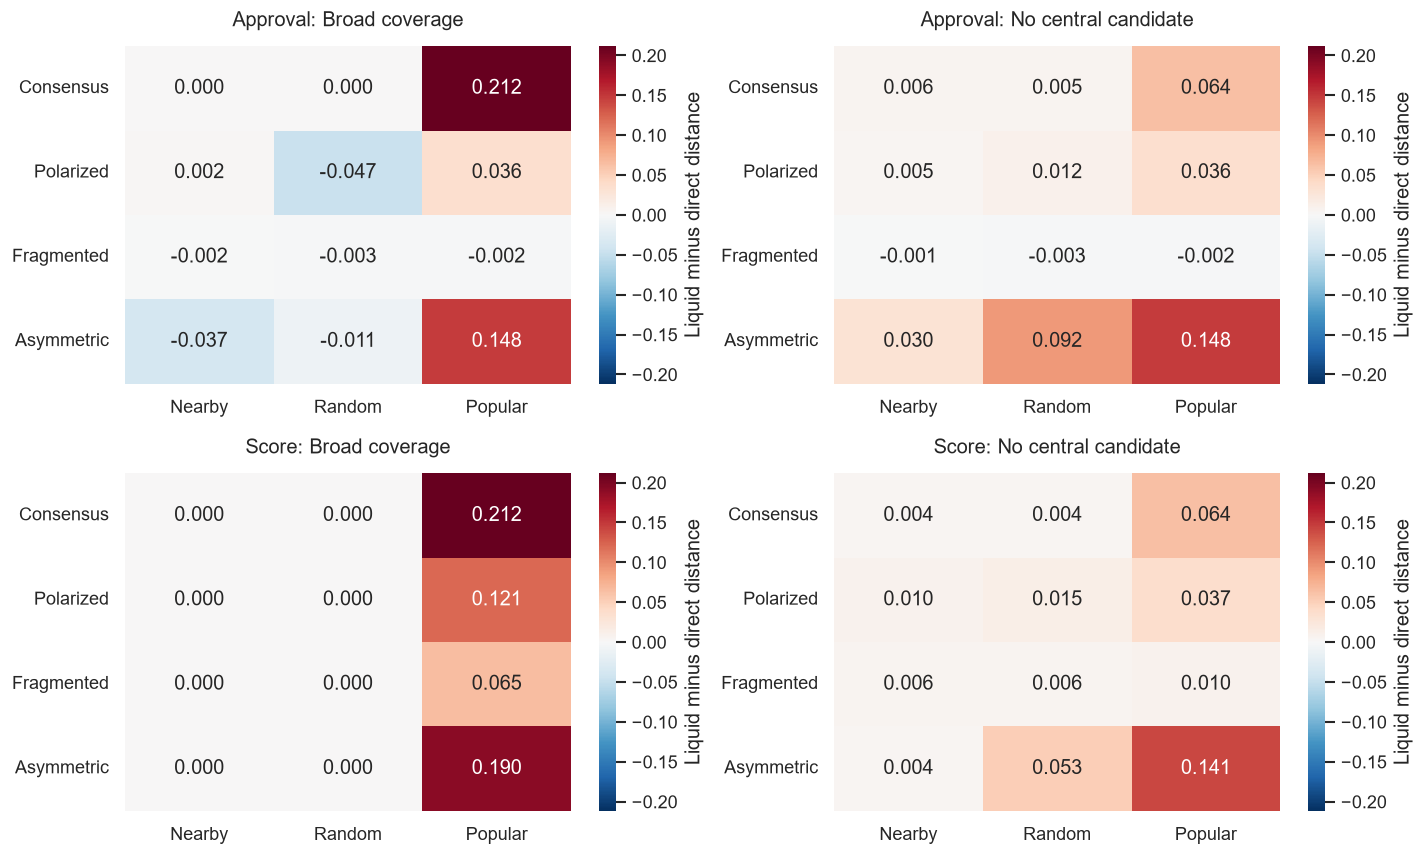

metric              distance_delta distance 95% interval  worst_group_delta  \
system   mechanism                                                            
Approval Nearby              0.000       [-0.002, 0.004]             -0.044   
         Popular             0.080        [0.071, 0.089]             -0.017   
         Random              0.006       [-0.005, 0.018]             -0.094   
Score    Nearby              0.003        [0.002, 0.004]             -0.014   
         Popular             0.105        [0.097, 0.113]              0.109   
         Random              0.010        [0.008, 0.011]             -0.040   

metric              prefer_liquid  prefer_direct  indifferent  largest_share  
system   mechanism                                                            
Approval Nearby             0.134          0.154        0.712          0.241  
         Popular            0.349          0.630        0.021          0.742  
         Random             0.266          0.293        0.441          0.149  
Score    Nearby             0.082          0.092        0.826          0.241  
         Popular            0.289          0.638        0.073          0.742  
         Random             0.129          0.160        0.712          0.149

In [15]:
selected = liquid_results[liquid_results.fraction == SELECTED_FRACTION]
scenario_effects = summarize_by_seed(selected, ["system", "slate", "family", "mechanism"],
                                     ["distance_delta"], BOOTSTRAP_DRAWS)
limit = max(abs(scenario_effects["mean"]).max(), 0.001)
fig, axes = plt.subplots(2, 2, figsize=(12, 7.3))
for row, rule in enumerate(["Approval", "Score"]):
    for col, slate in enumerate(CONFIG.slates):
        table = scenario_effects[(scenario_effects.system == rule) & (scenario_effects.slate == slate)]
        values = table.pivot(index="family", columns="mechanism", values="mean").reindex(
            index=CONFIG.families, columns=MECHANISMS)
        sns.heatmap(values, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
                    vmin=-limit, vmax=limit, ax=axes[row, col],
                    cbar_kws={"label": "Liquid minus direct distance"})
        axes[row, col].set(title=f"{rule}: {slate}", xlabel="", ylabel="")
        axes[row, col].tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.show()

paired_summary = summarize_by_seed(
    selected, ["system", "mechanism"],
    ["distance_delta", "worst_group_delta", "prefer_liquid", "prefer_direct", "indifferent",
     "largest_share", "unrepresented_power"], BOOTSTRAP_DRAWS,
)
paired_table = paired_summary.pivot(index=["system", "mechanism"], columns="metric", values="mean")
intervals = paired_summary[paired_summary.metric == "distance_delta"].set_index(["system", "mechanism"])
paired_table["distance 95% interval"] = intervals.apply(lambda r: f"[{r.low:.3f}, {r.high:.3f}]", axis=1)
display(paired_table[["distance_delta", "distance 95% interval", "worst_group_delta",
                      "prefer_liquid", "prefer_direct", "indifferent", "largest_share"]].round(3))


With the default design at a delegation fraction of 0.75, Nearby liquid score
has a population distance approximately 0.003 above direct score, while its
largest group mean distance is approximately 0.014 lower. Its population
distance remains below plurality in the pooled comparison. Thus, comparison
with another electoral rule and comparison with the matching direct baseline
lead to different assessments.

For approval, the pooled Nearby population-distance change is close to zero,
but the scenario effects differ. In the asymmetric electorate, the change is
approximately -0.037 with the broad slate and +0.030 when the central candidate
is removed. The pooled result therefore conceals dependence on candidate supply.
The Popular stress test increases pooled population distance by approximately
0.080 for approval and 0.105 for score.

These observations are specific to the default simulation. Score's direct
baseline is distance-optimal by construction; worst-group distance measures
an additional objective. The preference shares also distinguish a strict
preference for one outcome from indifference when both systems elect the same
candidate. None of these comparisons establishes a universal system ranking.


---
## 9. What can we take away?

Liquid democracy gives voters a choice: cast their own ballot or let someone
else vote on their behalf. It can work with different ways of choosing a winner,
including the approval and score rules used here. Delegation changes whose
preferences carry weight, so the choice of delegate matters as much as the
fact that delegation is allowed.

In our examples, choosing delegates with similar views usually keeps the result
closer to what voters would choose for themselves than concentrating power in
one delegate at one end of the political space. Every person's voting power can
still be counted even when the winner poorly reflects many people's views.
Counting everyone's power and representing everyone's preferences are different
things.

There is also no single answer to whether liquid democracy does better than
standard voting. In the comparison above, liquid score with nearby delegates
does better than plurality at choosing a candidate close to voters on average.
Yet it does slightly worse on that measure than letting everyone cast their own
score ballot. The candidates on offer can also change whether delegation helps
or hurts, as the approval results show.

Finally, a result that suits voters better on average need not suit every group
better. Nearby delegation under score voting slightly worsens the average in
this experiment while improving the position of the group furthest from the
winner. Which outcome we prefer depends partly on what we want an election to
achieve.
